In [1]:
#4.1
x = [1,2,3,10]
y = [10, 20, 30, 40]
z=[]
for a,b in zip(x,y): z.append(a+b)
print(z)
def add(x,y):
    return x+y
zmap=map(add,x,y)
print(list(zmap))

[11, 22, 33, 50]
[11, 22, 33, 50]


In [12]:
#4.3
import numpy as np
player=input("Play R, P or S")
hands=['R','P','S']
#the machine's choice
machine=np.random.randint(0,len(hands))
print(hands[machine])
if hands.index(player)-machine%3==0:
    """if the same hand happens"""
    print("Draw")
elif hands.index(player)-machine%3==1:
    """checks whether the player wins"""
    print("Player wins")
else:
    print("Machine wins")

Play R, P or S R


P
Machine wins


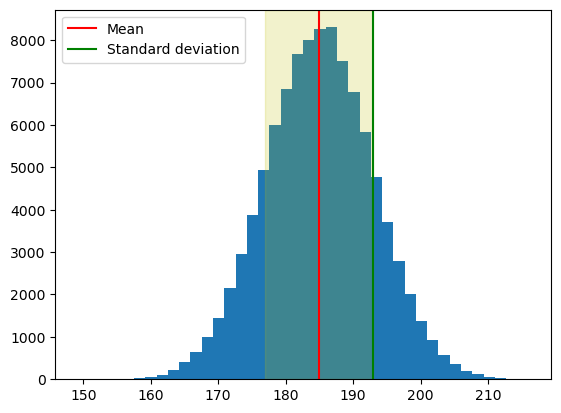

input h:  180


The probability that someone is shorter than 180 is 0.26700994763562513
The probability that someone is in 1 sigma of the mean is 0.6826894921370852


In [13]:
#4.4
import matplotlib.pyplot as plt
from scipy.stats import norm
dist=np.random.normal(185,8,100000)
plt.hist(dist,bins=40)
dev=dist.std()
mean=dist.mean()
plt.axvline(mean, label="Mean", color='r')
plt.axvline(mean+dev, label="Standard deviation", color='g')
plt.axvspan(mean-dev,mean+dev, color='y',alpha=0.2)
plt.legend()
plt.show()
h=int(input("input h: "))
prob1=norm.cdf(h, mean, dev)
prob2=1-2*norm.cdf(mean-dev, mean, dev)
print(f"The probability that someone is shorter than {h} is {prob1}")
print(f"The probability that someone is in 1 sigma of the mean is {prob2}")

In [14]:
#4.6
eq=input("Write the equation in function of x: ")
a=float(input("Enter the lower limit: "))
b=float(input("Enter the upper limit: "))
def montecarlo(func, a, b, n):
    vals=np.random.uniform(a,b,n)
    sigma=0
    for x in vals:
        sigma+=eval(func)
    return sigma*(b-a)/n
print("An approximation for the integral is ",montecarlo(eq,a,b,10000))

Write the equation in function of x:  x
Enter the lower limit:  0
Enter the upper limit:  1


An approximation for the integral is  0.4998509667116184


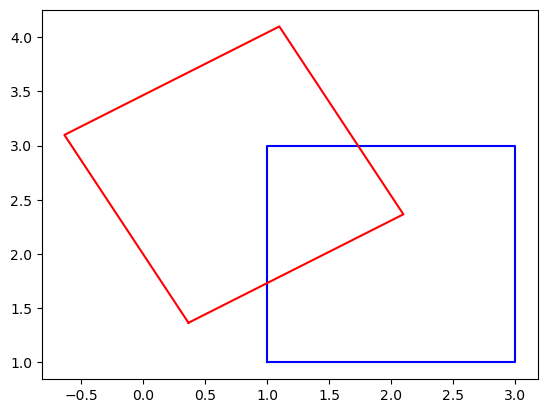

In [15]:
#4.12
x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])
z=x+y*1j
theta=30
rotor=np.cos(np.radians(theta))+np.sin(np.radians(theta))*1j
plt.plot(x,y,color='b')
zr=z*rotor
plt.plot(zr.real,zr.imag, color='r')

In [17]:
#4.14
def funcfilter(func,seq):
    seqar=np.atleast_1d(seq)
    seqpos=[]
    for i in seqar:
        if i>0:
            seqpos.append(i)
    return func(seqpos)

sq = np.array([-100, -10, 0, 10, 100])
result = funcfilter(np.log10, sq)
print("Result log10:", result)

Result log10: [-inf -inf -inf   0.   0.]


C:\Users\balin\AppData\Local\Temp\ipykernel_40492\178888472.py:6: RuntimeWarning: divide by zero encountered in log10
  return func(seqar)


In [7]:
#4.16
from scipy.integrate import quad
from astropy.cosmology import Planck18

H0 = Planck18.H0.value
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0
H0/=3.09*10**19
z=2
def Int(z):
    H=H0*(Om0*(1+z)**3+Ode0)**0.5
    return 1/((1+z)*H)
tl,error=quad(Int, 0, z)
tl/=3600*24*365.25*10**9
print(f"z={z} was {tl:.3f} Gyrs ago")

z=2 was 10.541 Gyrs ago


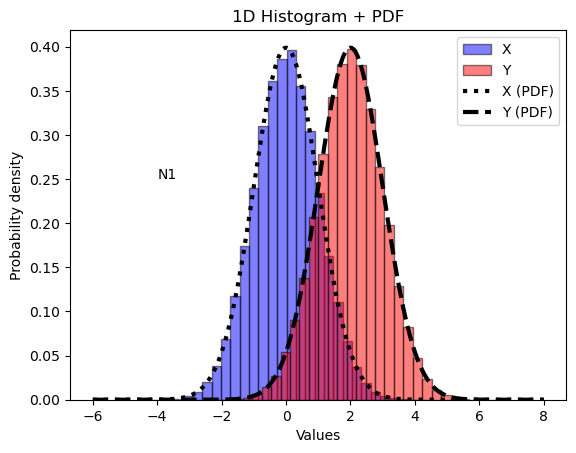

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.ticker as ticker

X = np.random.normal(0,1,100000)
Y = np.random.normal(2,1,100000)
counts_X, bins_X, _ = plt.hist(X, bins=30, density=True, color='b', alpha=0.5, label='X', edgecolor='k')
counts_Y, bins_Y, _ = plt.hist(Y, bins=30, density=True, color='r', alpha=0.5, label='Y', edgecolor='k')

x = np.linspace(-6,8,1000)
Xpdf = norm.pdf(x,0,1)
Ypdf = norm.pdf(x,2,1)
plt.plot(x, Xpdf, linestyle='dotted', linewidth=3, color='k', label='X (PDF)')
plt.plot(x, Ypdf, linestyle='dashed', linewidth=3, color='k', label='Y (PDF)')
plt.xlabel("Values")
plt.ylabel("Probability density")
plt.title("1D Histogram + PDF")
plt.annotate('N1',(-4,0.25))


plt.legend()
plt.show()

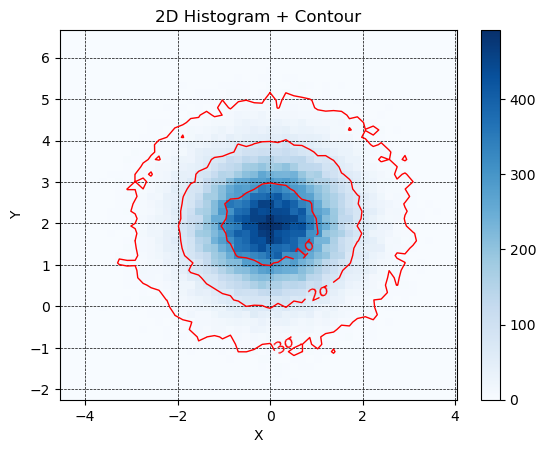

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

X = np.random.normal(0, 1, 100000)
Y = np.random.normal(2, 1, 100000)

fig, ax = plt.subplots()
h = ax.hist2d(X, Y, bins=50, cmap='Blues')
plt.colorbar(h[3], ax=ax)
counts = h[0]
xedges = h[1]
yedges = h[2]

xcenters = 0.5 * (xedges[:-1] + xedges[1:])
ycenters = 0.5 * (yedges[:-1] + yedges[1:])
Xgrid, Ygrid = np.meshgrid(xcenters, ycenters)

counts_norm = counts.T / counts.sum()
sorted=np.sort()
dev=X.std()
levels = [] 
contours=ax.contour(Xgrid, Ygrid, counts_norm, levels=levels, colors='red', linewidths=1)
ax.clabel(contours, fmt={levels[0]: r'3$\sigma$', levels[1]: r'2$\sigma$', levels[2]: r'1$\sigma$'},
          inline=True, fontsize=12, manual=False)

ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.grid(which='major', linestyle='dashed', linewidth=0.5, color='k')
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("2D Histogram + Contour")

plt.show()